In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
#from utils import *

## Loading in model data

In [3]:
df = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")
var_snowd = df["SNOW_DEPTH"]
var_snowd

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\madel\\Code\\GeoNorth\\run_0\\TVC_1995-2014.nc'

## Observational Plots

In [ ]:
obs1 = obs_data_parse("TVC_obs/snow_depth/TVC_SnowDepth_1.68mSR50A.txt")
obs2 = obs_data_parse("TVC_obs/snow_depth/TVC_SnowDepth_1.47mSR50A.txt")

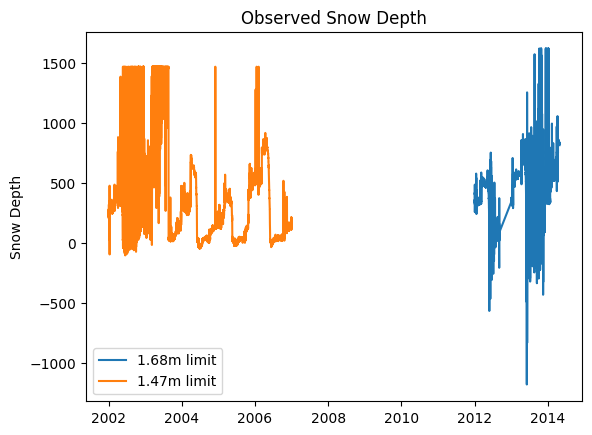

In [ ]:
plt.plot(obs1["time"], obs1["obs_depth"], label= "1.68m limit")
plt.plot(obs2["time"], obs2["obs_depth"], label= "1.47m limit")
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend()
plt.show()

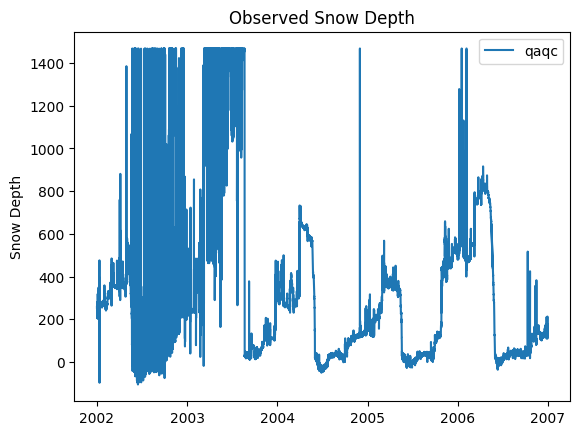

In [ ]:
obsq = obs_data_parse("TVC_obs/TVC_snow_depth_1.47m_qaqc.txt")

plt.plot(obsq["time"], obsq["obs_depth"], label= "qaqc")
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend()
plt.show()

Seems like the 1.68 data has negative values for some reason. Both datasets also max out at their respective sensor location, so 1.68 and 1.47.

## Combining data

first we check the units of the data.

In [ ]:
var_snowd

<xarray.DataArray 'SNOW_DEPTH' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

## Insert any conversions or other data manipulation

Its in meters so I'm going to change the observational data to meters to match. For now, I'll also be removing any negative values.

In [ ]:
obs1["obs_depth"] = obs1["obs_depth"]/1000
obs2["obs_depth"] = obs2["obs_depth"]/1000

obs1_cleaned = obs1[obs1["obs_depth"] >= 0]
obs2_cleaned = obs2[obs2["obs_depth"] >= 0]

#what happens if I threshold the data
obs1_cleaned = obs1_cleaned[obs1_cleaned["obs_depth"] <= 1.67]
obs2_cleaned = obs2_cleaned[obs2_cleaned["obs_depth"] <= 1.46]

In [ ]:
print(obs1_cleaned["time"][0])

2012-01-01 07:30:00+00:00


plot to check

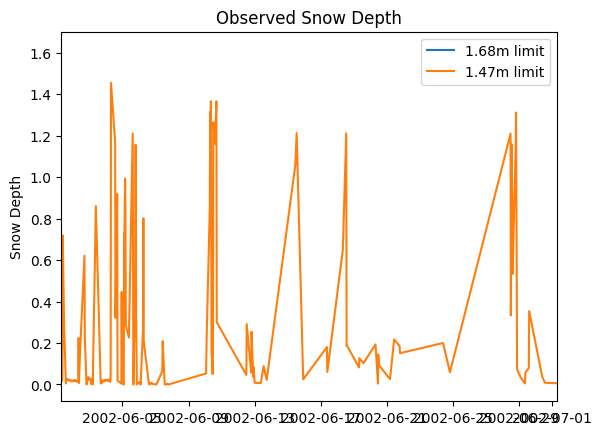

In [ ]:
plt.plot(obs1_cleaned["time"], obs1_cleaned["obs_depth"], label= "1.68m limit")
plt.plot(obs2_cleaned["time"], obs2_cleaned["obs_depth"], label= "1.47m limit")
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.xlim(pd.Timestamp('2002-06-01 07:30:00+00:00'), pd.Timestamp('2002-07-01 07:30:00+00:00'))
plt.legend()
plt.show()

looks good so let's plot all the data

In [ ]:
sim = var_snowd.copy()
sim['time'] = sim.indexes['time'].to_datetimeindex()


C:\Users\madel\AppData\Local\Temp\ipykernel_27040\891719653.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
C:\Users\madel\AppData\Local\Temp\ipykernel_27040\891719653.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


In [ ]:
obs1_cleaned["time"] = pd.to_datetime(obs1_cleaned["time"])
obs2_cleaned["time"] = pd.to_datetime(obs2_cleaned["time"])

obs_concat = pd.concat([obs2_cleaned, obs1_cleaned], ignore_index=True)

print(obs_concat)
obs_concat.sort_values(by=["time"])

print(obs_concat)

                            time  obs_depth
0      2002-01-01 07:30:00+00:00      0.258
1      2002-01-01 08:00:00+00:00      0.256
2      2002-01-01 08:30:00+00:00      0.252
3      2002-01-01 09:00:00+00:00      0.250
4      2002-01-01 09:30:00+00:00      0.254
...                          ...        ...
106496 2014-04-26 16:00:00+00:00      0.818
106497 2014-04-26 16:30:00+00:00      0.815
106498 2014-04-26 17:00:00+00:00      0.818
106499 2014-04-26 17:30:00+00:00      0.816
106500 2014-04-26 18:00:00+00:00      0.814

[106501 rows x 2 columns]
                            time  obs_depth
0      2002-01-01 07:30:00+00:00      0.258
1      2002-01-01 08:00:00+00:00      0.256
2      2002-01-01 08:30:00+00:00      0.252
3      2002-01-01 09:00:00+00:00      0.250
4      2002-01-01 09:30:00+00:00      0.254
...                          ...        ...
106496 2014-04-26 16:00:00+00:00      0.818
106497 2014-04-26 16:30:00+00:00      0.815
106498 2014-04-26 17:00:00+00:00      0.818
10649

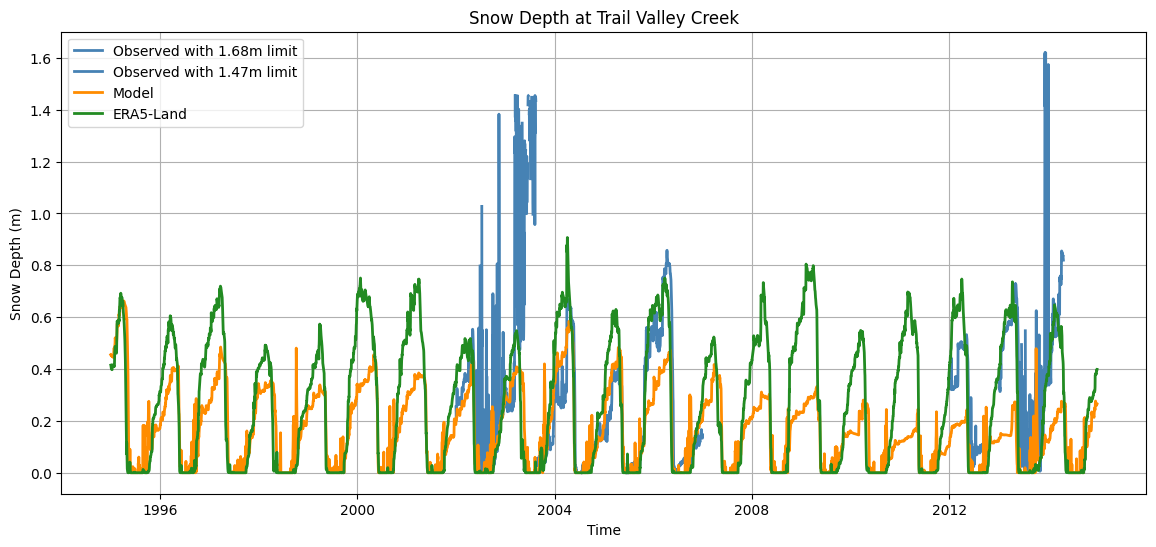

In [ ]:
import glob
# Load and combine the two ERA5 files
files = ["era5_west/data_0.nc", "era5_west_2/data_0.nc"]
era5 = xr.open_mfdataset(files, combine="by_coords")

# Extract Smith Creek
era5_sc = era5["sde"].sel(
    latitude=68.7462,
    longitude=-133.5017 % 360,
    method="nearest"
)

# Convert pandas → xarray
#obs = obs_concat.set_index("time").to_xarray()
final_obs1 = obs1_cleaned.set_index("time").to_xarray()
final_obs2 = obs2_cleaned.set_index("time").to_xarray()

# Resample observational data to daily frequency
#obs_daily = obs.resample(time="1D").mean()
final_obs1_daily = final_obs1.resample(time="1D").mean()
final_obs2_daily = final_obs2.resample(time="1D").mean()

plt.figure(figsize=(14,6))

# Observed 1
plt.plot(
    final_obs1_daily["time"].values,
    final_obs1_daily["obs_depth"].values,
    label="Observed with 1.68m limit",
    color = 'steelblue',
    linewidth=2
)

# Observed 2
plt.plot(
    final_obs2_daily["time"].values,
    final_obs2_daily["obs_depth"].values,
    label="Observed with 1.47m limit",
    color = 'steelblue',
    linewidth=2
)

# Simulated
plt.plot(
    sim["time"].values,
    sim.values,
    label="Model",
    color = 'darkorange',
    linewidth=2
)

plt.plot(
    era5_sc["valid_time"].values,
    era5_sc.values,
    label="ERA5-Land",
    color='forestgreen',
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Snow Depth (m)")
plt.title("Snow Depth at Trail Valley Creek")
plt.grid(True)
#plt.xlim(pd.Timestamp('2001-01-01 07:30:00+00:00'), pd.Timestamp('2014-12-31 07:30:00+00:00'))
plt.legend()
plt.savefig("0_final_images/TVC_snow_depth.png", bbox_inches='tight')
plt.show()
